In [1]:
from aoi_marl_qlearning import *

In [2]:
network = WirelessSensorNetwork(num_sensors=NUM_SENSORS)
print(f"Sensors: {NUM_SENSORS}")
print(f"A_MAX: {A_MAX}")
print(f"Time slots: {num_time_slots}")
print(f"Episodes: {num_episodes}")
print(f"Power Budget: {POWER_BUDGET}")

Sensors: 10
A_MAX: 40
Time slots: 100
Episodes: 50000
Power Budget: 30


In [3]:
epsilon = epsilon_start

# ***TRAINING LOOP***
for it in range(num_episodes):
    if it % 10000 == 0:
        print(f"Episode: {it}")

    episode_return = 0

    for t in range(num_time_slots):
        actions = []
        for sensor in network.sensors:
            state = sensor.get_state()
            actions.append(sensor.choose_action(state, epsilon))

        step_reward = network.step(actions)
        episode_return += step_reward

    network.past_rewards.append(episode_return)
    epsilon *= epsilon_decay
    network.reset()

Episode: 0
Episode: 10000
Episode: 20000
Episode: 30000
Episode: 40000


In [4]:
# ***EVALUATION LOOP***
avg_aoi = [0.0] * num_time_slots

for it in range(num_eval_episodes):
    network.reset()

    for t in range(num_time_slots):
        actions = []
        for sensor in network.sensors:
            state = sensor.get_state()
            actions.append(sensor.choose_action(state, epsilon=0.0))  # purely greedy

        network.step(actions)
        avg_aoi[t] += network.get_avg_aoi()

avg_aoi = [aoi / (num_eval_episodes) for aoi in avg_aoi]

In [5]:
for i, s in enumerate(network.sensors):
    print(f"Sensor {i} Q entries:", len(s.q_table))
    some = list(s.q_table.items())[:400]
    for k, v in some:
        print(" ", k, "->", round(v, 3))

Sensor 0 Q entries: 318
  ((1, 0, 1), 1) -> -126.421
  ((2, 2, 1), 1) -> -121.949
  ((3, 2, 1), 1) -> -143.869
  ((4, 2, 1), 1) -> -148.685
  ((5, 2, 1), 1) -> -172.881
  ((6, 2, 1), 0) -> -148.623
  ((7, 0, 1), 0) -> -97.997
  ((8, 0, 1), 1) -> -195.841
  ((9, 2, 0), 0) -> -217.322
  ((10, 0, 0), 1) -> -143.044
  ((11, 2, 0), 0) -> -204.017
  ((12, 0, 0), 1) -> -288.744
  ((13, 2, 0), 0) -> -268.157
  ((14, 0, 0), 1) -> -304.472
  ((15, 2, 0), 1) -> -326.243
  ((16, 2, 0), 0) -> -324.786
  ((17, 0, 0), 1) -> -358.381
  ((18, 2, 0), 1) -> -411.079
  ((19, 2, 0), 1) -> -410.258
  ((20, 2, 0), 1) -> -447.151
  ((21, 2, 0), 0) -> -390.84
  ((22, 0, 0), 1) -> -45.192
  ((23, 2, 0), 0) -> -483.381
  ((24, 0, 0), 0) -> -494.043
  ((25, 0, 0), 0) -> -491.995
  ((26, 0, 0), 0) -> -461.129
  ((27, 0, 0), 0) -> -565.101
  ((28, 0, 0), 0) -> -584.104
  ((29, 0, 0), 0) -> -591.93
  ((30, 0, 0), 0) -> -597.107
  ((31, 0, 0), 0) -> -597.886
  ((32, 0, 0), 0) -> -585.536
  ((33, 0, 0), 0) -> -543.542

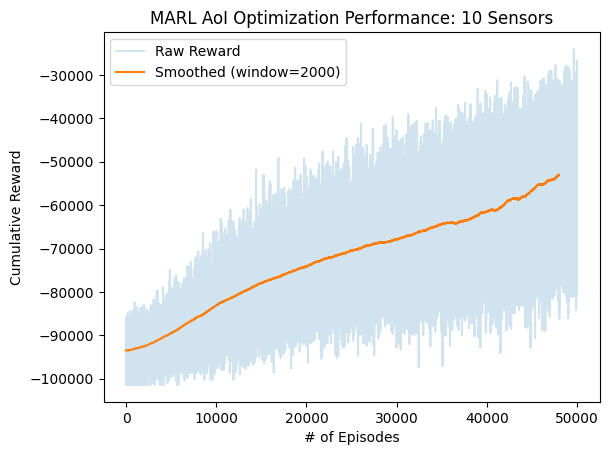

In [6]:
window = 2000
smoothed = np.convolve(network.past_rewards, np.ones(window) / window, mode='valid')

plt.plot(network.past_rewards, alpha=0.2, label="Raw Reward")
plt.plot(smoothed, label=f"Smoothed (window={window})")
plt.title(f"MARL AoI Optimization Performance: {network.num_sensors} Sensors")
plt.xlabel("# of Episodes")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.show()

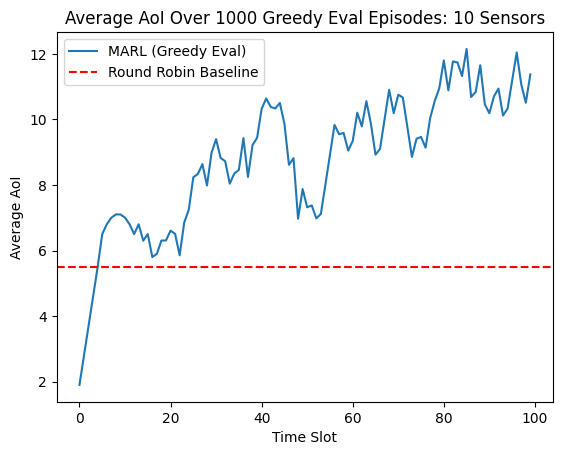

In [7]:
baseline = (NUM_SENSORS + 1) / 2

plt.plot(avg_aoi, label="MARL (Greedy Eval)")
plt.axhline(y=baseline, linestyle="--", label="Round Robin Baseline", color="red")

plt.title(f"Average AoI Over {num_eval_episodes} Greedy Eval Episodes: {network.num_sensors} Sensors")
plt.xlabel("Time Slot")
plt.ylabel("Average AoI")
plt.legend()
plt.show()

In [8]:
mean_aoi = sum(avg_aoi) / len(avg_aoi)
print(f"The mean is: {mean_aoi}")

The mean is: 8.789084000000003
